# Heat Equation: MLP-PINN Baseline vs PIKAN

Goal:
1. Build an MLP-PINN baseline for the 1D heat equation.
2. Replace only the MLP backbone with KAN to get PIKAN.
3. Keep the PDE, sampled training points, loss functions, optimizer, learning rate, and training epochs the same.
4. Match the trainable parameter count between MLP-PINN and PIKAN as closely as possible.
5. Compare loss curves, relative L2 error, parameter efficiency, convergence speed, and sensitivity.

## Problem Setup

We solve the 1D heat equation:

\[
u_t = \alpha u_{xx}, \quad x \in [0,1], \quad t \in [0,1]
\]

with boundary conditions:

\[
u(0,t)=0, \quad u(1,t)=0
\]

and initial condition:

\[
u(x,0)=\sin(\pi x)
\]

The analytical solution is:

\[
u(x,t)=e^{-\pi^2\alpha t}\sin(\pi x)
\]

In [1]:
import time
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Device: cuda


## Step 1: MLP-PINN Baseline

The MLP-PINN uses a standard fully connected neural network to approximate:

\[
u_\theta(x,t)
\]

The training loss is:

\[
L = L_{PDE}+L_{boundary}+L_{initial}
\]

In [2]:
class MLP_PINN(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=64, out_dim=1, depth=4):
        super().__init__()

        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(depth - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

## Step 2: PIKAN Model

PIKAN keeps the same PINN loss, but replaces the MLP backbone with KAN.

KAN uses learnable edge functions instead of fixed scalar weights. In the classical KAN formulation, each edge function can be represented by spline basis functions:

\[
\phi_{ij}(x)=\sum_k c_{ijk}B_k(x)
\]

Here, only the backbone is changed. The PDE residual loss, boundary loss, initial loss, optimizer, and training data stay the same.

In [3]:
# If efficient-kan is not installed, this cell installs it automatically.
# In many course environments, you may also install it manually with:
# pip install efficient-kan

try:
    from efficient_kan import KAN
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "efficient-kan", "-q"])
    from efficient_kan import KAN


class KAN_PINN(nn.Module):
    def __init__(
        self,
        in_dim=2,
        hidden_dim=20,
        out_dim=1,
        depth=4,
        grid_size=5,
        spline_order=3
    ):
        super().__init__()
        width = [in_dim] + [hidden_dim] * depth + [out_dim]
        self.net = KAN(
            width,
            grid_size=grid_size,
            spline_order=spline_order
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

## Step 3: Loss Functions

The two models use the exact same PINN losses.

In [4]:
def pde_residual_loss(model, x, t, alpha=0.01):
    x = x.clone().detach().requires_grad_(True)
    t = t.clone().detach().requires_grad_(True)

    u = model(x, t)

    u_t = torch.autograd.grad(
        u, t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    residual = u_t - alpha * u_xx
    return torch.mean(residual ** 2)


def boundary_loss(model, t_b):
    x_left = torch.zeros_like(t_b)
    x_right = torch.ones_like(t_b)

    u_left = model(x_left, t_b)
    u_right = model(x_right, t_b)

    return torch.mean(u_left ** 2) + torch.mean(u_right ** 2)


def initial_loss(model, x_i):
    t_i = torch.zeros_like(x_i)
    u_pred = model(x_i, t_i)
    u_true = torch.sin(torch.pi * x_i)

    return torch.mean((u_pred - u_true) ** 2)


def total_loss(model, x_f, t_f, x_i, t_b, alpha=0.01):
    loss_pde = pde_residual_loss(model, x_f, t_f, alpha)
    loss_bc = boundary_loss(model, t_b)
    loss_ic = initial_loss(model, x_i)

    loss = loss_pde + loss_bc + loss_ic

    logs = {
        "total": loss.item(),
        "pde": loss_pde.item(),
        "bc": loss_bc.item(),
        "ic": loss_ic.item()
    }

    return loss, logs

## Step 4: Use the Same Sampled Training Points

For fair comparison, both MLP-PINN and PIKAN are trained on the same collocation, boundary, and initial points.

In [5]:
def make_training_data(
    n_f=1000,
    n_i=200,
    n_b=200,
    device="cpu",
    seed=42
):
    gen = torch.Generator(device="cpu")
    gen.manual_seed(seed)

    x_f = torch.rand(n_f, 1, generator=gen).to(device)
    t_f = torch.rand(n_f, 1, generator=gen).to(device)

    x_i = torch.rand(n_i, 1, generator=gen).to(device)
    t_b = torch.rand(n_b, 1, generator=gen).to(device)

    return {
        "x_f": x_f,
        "t_f": t_f,
        "x_i": x_i,
        "t_b": t_b
    }


train_data = make_training_data(device=device, seed=42)

print(train_data["x_f"].shape)
print(train_data["t_f"].shape)
print(train_data["x_i"].shape)
print(train_data["t_b"].shape)

torch.Size([1000, 1])
torch.Size([1000, 1])
torch.Size([200, 1])
torch.Size([200, 1])


## Step 5: Match Parameter Counts

Since KAN has more parameters per connection than MLP, using the same hidden dimension would not be fair.  
Here we automatically choose a KAN hidden dimension whose trainable parameter count is closest to the MLP baseline.

In [6]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def find_best_kan_hidden_dim(
    target_params,
    depth=4,
    grid_size=5,
    spline_order=3,
    candidates=range(4, 81)
):
    records = []

    for h in candidates:
        try:
            model = KAN_PINN(
                hidden_dim=h,
                depth=depth,
                grid_size=grid_size,
                spline_order=spline_order
            )
            n_params = count_trainable_params(model)
            records.append((h, n_params, abs(n_params - target_params)))
        except Exception as e:
            print(f"Skipping hidden_dim={h}: {e}")

    best = min(records, key=lambda x: x[2])
    return best, records


mlp_hidden_dim = 64
mlp_depth = 4

model_mlp = MLP_PINN(hidden_dim=mlp_hidden_dim, depth=mlp_depth)
mlp_params = count_trainable_params(model_mlp)

best_kan, kan_records = find_best_kan_hidden_dim(
    target_params=mlp_params,
    depth=mlp_depth,
    grid_size=5,
    spline_order=3
)

kan_hidden_dim, kan_params, param_gap = best_kan

print("MLP hidden_dim:", mlp_hidden_dim)
print("MLP params:", mlp_params)
print("Best KAN hidden_dim:", kan_hidden_dim)
print("KAN params:", kan_params)
print("Parameter gap:", param_gap)
print("Parameter ratio KAN/MLP:", kan_params / mlp_params)

MLP hidden_dim: 64
MLP params: 12737
Best KAN hidden_dim: 20
KAN params: 12600
Parameter gap: 137
Parameter ratio KAN/MLP: 0.9892439349925414


## Step 6: Training Loop

The training loop returns the total loss and each component loss at every epoch.

In [7]:
def train(
    model,
    train_data,
    epochs=5000,
    lr=1e-3,
    alpha=0.01,
    device="cpu",
    print_every=500
):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "total": [],
        "pde": [],
        "bc": [],
        "ic": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        loss, logs = total_loss(
            model,
            train_data["x_f"],
            train_data["t_f"],
            train_data["x_i"],
            train_data["t_b"],
            alpha
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        for key in history:
            history[key].append(logs[key])

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:5d} | "
                f"Loss={logs['total']:.6e} | "
                f"PDE={logs['pde']:.6e} | "
                f"BC={logs['bc']:.6e} | "
                f"IC={logs['ic']:.6e}"
            )

    train_time = time.time() - start_time

    return history, train_time

## Step 7: Train MLP-PINN and PIKAN

Both models use:
- same training points
- same PDE loss
- same boundary loss
- same initial loss
- same optimizer
- same learning rate
- same number of epochs

In [8]:
set_seed(42)

model_mlp = MLP_PINN(hidden_dim=mlp_hidden_dim, depth=mlp_depth).to(device)

print("MLP-PINN")
print("Trainable parameters:", count_trainable_params(model_mlp))

history_mlp, time_mlp = train(
    model_mlp,
    train_data=train_data,
    epochs=5000,
    lr=1e-3,
    alpha=0.01,
    device=device,
    print_every=500
)

print("MLP training time:", time_mlp)

MLP-PINN
Trainable parameters: 12737
Epoch     0 | Loss=3.839199e-01 | PDE=2.541453e-03 | BC=5.981724e-02 | IC=3.215612e-01
Epoch   500 | Loss=6.635946e-04 | PDE=5.577481e-04 | BC=6.605065e-05 | IC=3.979596e-05
Epoch  1000 | Loss=1.815917e-04 | PDE=1.486149e-04 | BC=2.278928e-05 | IC=1.018753e-05
Epoch  1500 | Loss=3.698590e-05 | PDE=3.156155e-05 | BC=4.548614e-06 | IC=8.757356e-07
Epoch  2000 | Loss=2.209801e-05 | PDE=1.879440e-05 | BC=2.646731e-06 | IC=6.568803e-07
Epoch  2500 | Loss=2.054314e-05 | PDE=1.656124e-05 | BC=2.845252e-06 | IC=1.136651e-06
Epoch  3000 | Loss=1.539756e-05 | PDE=1.264641e-05 | BC=1.817939e-06 | IC=9.332068e-07
Epoch  3500 | Loss=1.508153e-05 | PDE=1.220717e-05 | BC=1.810301e-06 | IC=1.064062e-06
Epoch  4000 | Loss=1.929152e-05 | PDE=1.528481e-05 | BC=2.605750e-06 | IC=1.400957e-06
Epoch  4500 | Loss=1.211574e-05 | PDE=9.770848e-06 | BC=1.293395e-06 | IC=1.051501e-06
MLP training time: 105.48268818855286


In [9]:
set_seed(42)

model_kan = KAN_PINN(
    hidden_dim=kan_hidden_dim,
    depth=mlp_depth,
    grid_size=5,
    spline_order=3
).to(device)

print("PIKAN")
print("Trainable parameters:", count_trainable_params(model_kan))

history_kan, time_kan = train(
    model_kan,
    train_data=train_data,
    epochs=5000,
    lr=1e-3,
    alpha=0.01,
    device=device,
    print_every=500
)

print("PIKAN training time:", time_kan)

PIKAN
Trainable parameters: 12600
Epoch     0 | Loss=5.604655e-01 | PDE=4.309732e-06 | BC=1.343472e-04 | IC=5.603269e-01
Epoch   500 | Loss=1.898510e-05 | PDE=1.635629e-05 | BC=3.601691e-07 | IC=2.268641e-06
Epoch  1000 | Loss=3.769779e-06 | PDE=3.064808e-06 | BC=2.695270e-07 | IC=4.354438e-07
Epoch  1500 | Loss=1.858068e-06 | PDE=1.549541e-06 | BC=1.260599e-07 | IC=1.824676e-07
Epoch  2000 | Loss=1.126753e-06 | PDE=9.780540e-07 | BC=7.027710e-08 | IC=7.842171e-08
Epoch  2500 | Loss=7.605079e-07 | PDE=6.785477e-07 | BC=4.603627e-08 | IC=3.592383e-08
Epoch  3000 | Loss=5.821615e-07 | PDE=5.101925e-07 | BC=4.450158e-08 | IC=2.746749e-08
Epoch  3500 | Loss=1.041769e-05 | PDE=4.477383e-07 | BC=7.428660e-06 | IC=2.541291e-06
Epoch  4000 | Loss=3.655603e-07 | PDE=3.432364e-07 | BC=1.509832e-08 | IC=7.225593e-09
Epoch  4500 | Loss=3.268562e-07 | PDE=3.008579e-07 | BC=1.821693e-08 | IC=7.781347e-09
PIKAN training time: 566.1012308597565


## Step 8: Analytical Reference and Relative L2 Error

In [10]:
def true_solution(x, t, alpha=0.01):
    return torch.exp(-(torch.pi ** 2) * alpha * t) * torch.sin(torch.pi * x)


def relative_l2_error(model, alpha=0.01, device="cpu", n_grid=100):
    model.eval()

    x = torch.linspace(0, 1, n_grid).reshape(-1, 1).to(device)
    t = torch.linspace(0, 1, n_grid).reshape(-1, 1).to(device)

    X, T = torch.meshgrid(
        x.squeeze(),
        t.squeeze(),
        indexing="ij"
    )

    x_flat = X.reshape(-1, 1)
    t_flat = T.reshape(-1, 1)

    with torch.no_grad():
        u_pred = model(x_flat, t_flat)
        u_true = true_solution(x_flat, t_flat, alpha)

    error = torch.norm(u_pred - u_true) / torch.norm(u_true)
    return error.item()


err_mlp = relative_l2_error(model_mlp, alpha=0.01, device=device)
err_kan = relative_l2_error(model_kan, alpha=0.01, device=device)

print("MLP-PINN Relative L2 Error:", err_mlp)
print("PIKAN Relative L2 Error:", err_kan)

MLP-PINN Relative L2 Error: 0.0038888747803866863
PIKAN Relative L2 Error: 9.28086374187842e-05


## Step 9: Loss Curve Comparison

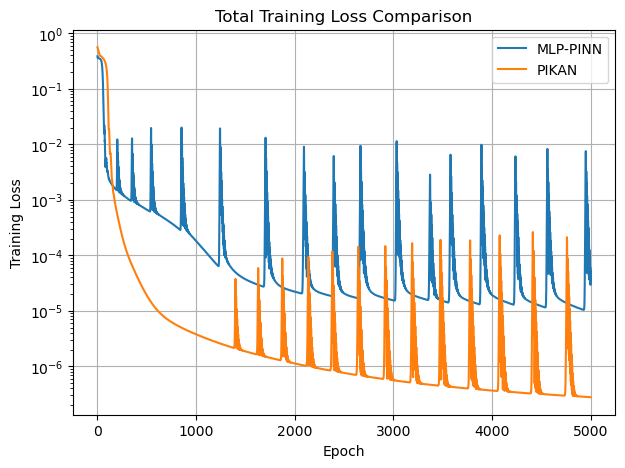

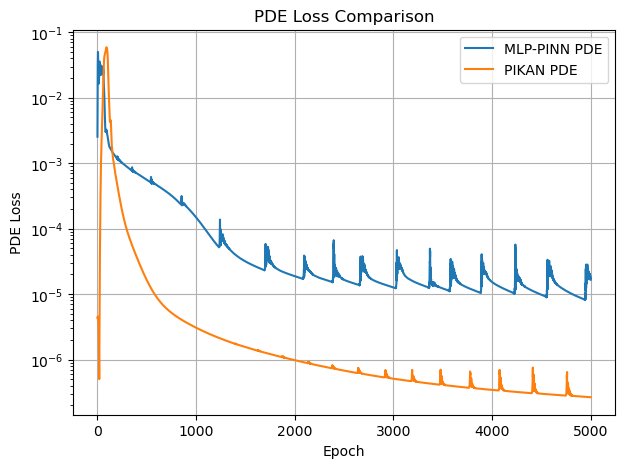

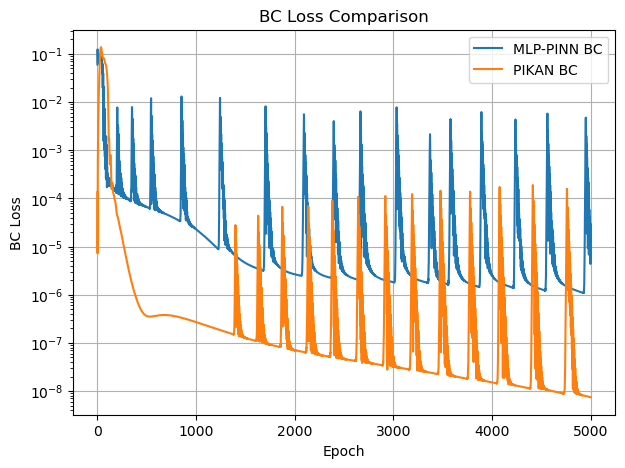

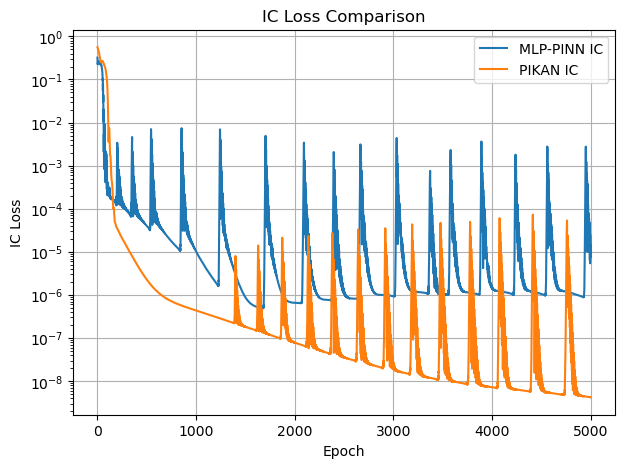

In [11]:
def plot_loss_curves(history_mlp, history_kan):
    plt.figure(figsize=(7, 5))
    plt.semilogy(history_mlp["total"], label="MLP-PINN")
    plt.semilogy(history_kan["total"], label="PIKAN")
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("Total Training Loss Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    for key in ["pde", "bc", "ic"]:
        plt.figure(figsize=(7, 5))
        plt.semilogy(history_mlp[key], label=f"MLP-PINN {key.upper()}")
        plt.semilogy(history_kan[key], label=f"PIKAN {key.upper()}")
        plt.xlabel("Epoch")
        plt.ylabel(f"{key.upper()} Loss")
        plt.title(f"{key.upper()} Loss Comparison")
        plt.legend()
        plt.grid(True)
        plt.show()


plot_loss_curves(history_mlp, history_kan)

## Step 10: Parameter Efficiency and Convergence Speed

Parameter efficiency is measured by:
1. final relative L2 error under similar parameter count
2. final loss under similar parameter count
3. number of epochs needed to reach a target loss

In [12]:
def first_epoch_below_threshold(loss_history, threshold):
    for i, value in enumerate(loss_history):
        if value <= threshold:
            return i
    return None


target_loss = 1e-4

mlp_epoch_to_target = first_epoch_below_threshold(history_mlp["total"], target_loss)
kan_epoch_to_target = first_epoch_below_threshold(history_kan["total"], target_loss)

summary = {
    "MLP-PINN": {
        "params": count_trainable_params(model_mlp),
        "final_loss": history_mlp["total"][-1],
        "relative_l2_error": err_mlp,
        "training_time_sec": time_mlp,
        "epoch_to_target_loss": mlp_epoch_to_target
    },
    "PIKAN": {
        "params": count_trainable_params(model_kan),
        "final_loss": history_kan["total"][-1],
        "relative_l2_error": err_kan,
        "training_time_sec": time_kan,
        "epoch_to_target_loss": kan_epoch_to_target
    }
}

summary

{'MLP-PINN': {'params': 12737,
  'final_loss': 5.162333764019422e-05,
  'relative_l2_error': 0.0038888747803866863,
  'training_time_sec': 105.48268818855286,
  'epoch_to_target_loss': 1127},
 'PIKAN': {'params': 12600,
  'final_loss': 2.7754742859542603e-07,
  'relative_l2_error': 9.28086374187842e-05,
  'training_time_sec': 566.1012308597565,
  'epoch_to_target_loss': 310}}

## Step 11: Visualization

For each model, plot:
1. predicted temperature field
2. true/reference temperature field
3. pointwise absolute error map

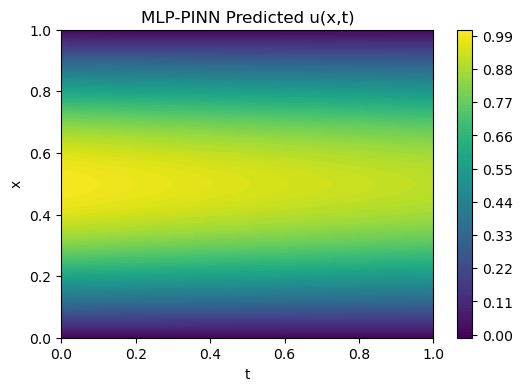

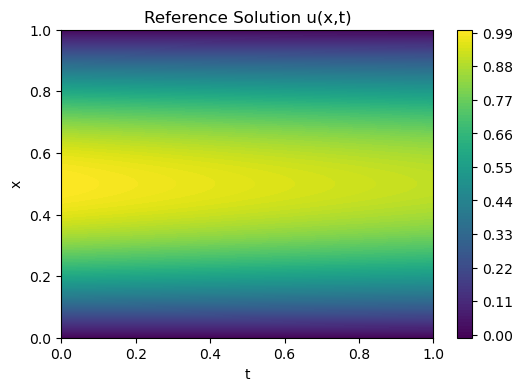

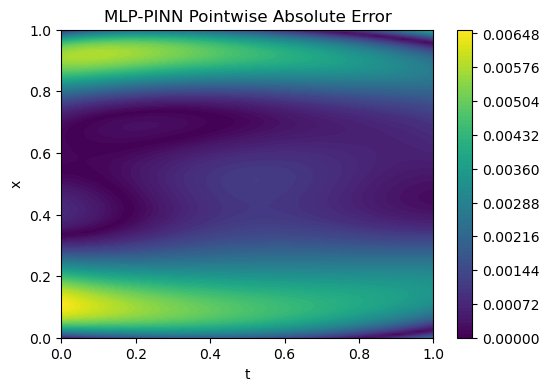

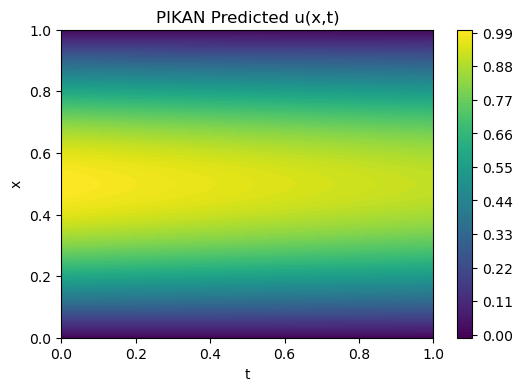

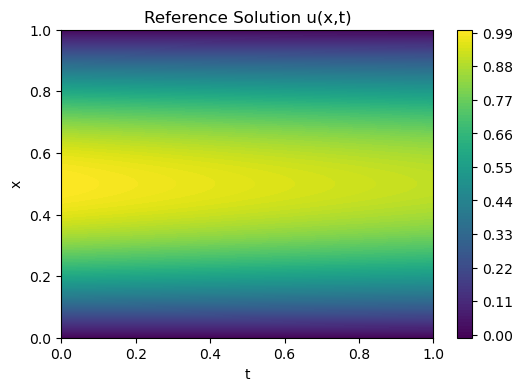

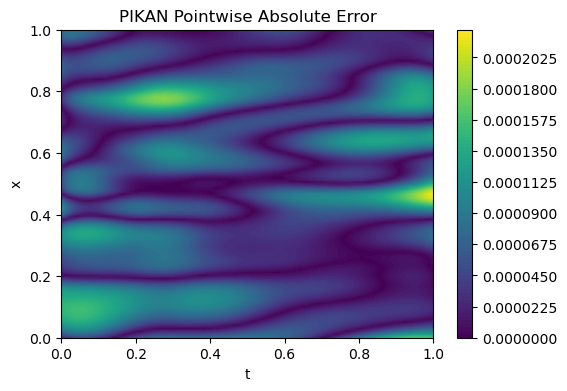

In [13]:
def plot_temperature_fields(model, model_name, alpha=0.01, device="cpu", n_grid=100):
    model.eval()

    x = torch.linspace(0, 1, n_grid).reshape(-1, 1).to(device)
    t = torch.linspace(0, 1, n_grid).reshape(-1, 1).to(device)

    X, T = torch.meshgrid(
        x.squeeze(),
        t.squeeze(),
        indexing="ij"
    )

    x_flat = X.reshape(-1, 1)
    t_flat = T.reshape(-1, 1)

    with torch.no_grad():
        U_pred = model(x_flat, t_flat).reshape(n_grid, n_grid)
        U_true = true_solution(x_flat, t_flat, alpha).reshape(n_grid, n_grid)
        U_error = torch.abs(U_pred - U_true)

    X_np = X.cpu().numpy()
    T_np = T.cpu().numpy()

    plt.figure(figsize=(6, 4))
    plt.contourf(T_np, X_np, U_pred.cpu().numpy(), levels=100)
    plt.colorbar()
    plt.xlabel("t")
    plt.ylabel("x")
    plt.title(f"{model_name} Predicted u(x,t)")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.contourf(T_np, X_np, U_true.cpu().numpy(), levels=100)
    plt.colorbar()
    plt.xlabel("t")
    plt.ylabel("x")
    plt.title("Reference Solution u(x,t)")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.contourf(T_np, X_np, U_error.cpu().numpy(), levels=100)
    plt.colorbar()
    plt.xlabel("t")
    plt.ylabel("x")
    plt.title(f"{model_name} Pointwise Absolute Error")
    plt.show()


plot_temperature_fields(model_mlp, "MLP-PINN", alpha=0.01, device=device)
plot_temperature_fields(model_kan, "PIKAN", alpha=0.01, device=device)

## Step 12: Sensitivity Study

This part tests sensitivity to learning rate and network depth.

To reduce runtime, the default setting below uses fewer epochs.  
For final reporting, increase `sensitivity_epochs` if needed.

In [14]:
def run_single_experiment(
    model_type,
    hidden_dim,
    depth,
    lr,
    train_data,
    epochs=1000,
    alpha=0.01,
    device="cpu"
):
    set_seed(42)

    if model_type == "MLP":
        model = MLP_PINN(hidden_dim=hidden_dim, depth=depth).to(device)
    elif model_type == "KAN":
        model = KAN_PINN(
            hidden_dim=hidden_dim,
            depth=depth,
            grid_size=5,
            spline_order=3
        ).to(device)
    else:
        raise ValueError("model_type must be 'MLP' or 'KAN'.")

    history, train_time = train(
        model,
        train_data=train_data,
        epochs=epochs,
        lr=lr,
        alpha=alpha,
        device=device,
        print_every=epochs + 1
    )

    rel_l2 = relative_l2_error(model, alpha=alpha, device=device)

    return {
        "model_type": model_type,
        "hidden_dim": hidden_dim,
        "depth": depth,
        "lr": lr,
        "params": count_trainable_params(model),
        "final_loss": history["total"][-1],
        "relative_l2_error": rel_l2,
        "training_time_sec": train_time
    }


# Optional sensitivity study.
# This can take time, so reduce epochs during testing.
sensitivity_epochs = 1000

sensitivity_results = []

for lr in [1e-4, 1e-3, 5e-3]:
    sensitivity_results.append(
        run_single_experiment(
            "MLP",
            hidden_dim=mlp_hidden_dim,
            depth=mlp_depth,
            lr=lr,
            train_data=train_data,
            epochs=sensitivity_epochs,
            device=device
        )
    )

    sensitivity_results.append(
        run_single_experiment(
            "KAN",
            hidden_dim=kan_hidden_dim,
            depth=mlp_depth,
            lr=lr,
            train_data=train_data,
            epochs=sensitivity_epochs,
            device=device
        )
    )

for depth in [2, 3, 4]:
    sensitivity_results.append(
        run_single_experiment(
            "MLP",
            hidden_dim=mlp_hidden_dim,
            depth=depth,
            lr=1e-3,
            train_data=train_data,
            epochs=sensitivity_epochs,
            device=device
        )
    )

    # For KAN, keep the selected hidden_dim fixed for a simple depth sensitivity test.
    sensitivity_results.append(
        run_single_experiment(
            "KAN",
            hidden_dim=kan_hidden_dim,
            depth=depth,
            lr=1e-3,
            train_data=train_data,
            epochs=sensitivity_epochs,
            device=device
        )
    )

sensitivity_results

Epoch     0 | Loss=3.839199e-01 | PDE=2.541453e-03 | BC=5.981724e-02 | IC=3.215612e-01
Epoch     0 | Loss=5.604655e-01 | PDE=4.309732e-06 | BC=1.343472e-04 | IC=5.603269e-01
Epoch     0 | Loss=3.839199e-01 | PDE=2.541453e-03 | BC=5.981724e-02 | IC=3.215612e-01
Epoch     0 | Loss=5.604655e-01 | PDE=4.309732e-06 | BC=1.343472e-04 | IC=5.603269e-01
Epoch     0 | Loss=3.839199e-01 | PDE=2.541453e-03 | BC=5.981724e-02 | IC=3.215612e-01
Epoch     0 | Loss=5.604655e-01 | PDE=4.309732e-06 | BC=1.343472e-04 | IC=5.603269e-01
Epoch     0 | Loss=6.794649e-01 | PDE=9.041015e-02 | BC=6.799399e-02 | IC=5.210608e-01
Epoch     0 | Loss=5.357339e-01 | PDE=9.834107e-04 | BC=1.321913e-03 | IC=5.334286e-01
Epoch     0 | Loss=9.470592e-01 | PDE=2.794069e-03 | BC=9.437371e-02 | IC=8.498914e-01
Epoch     0 | Loss=5.574976e-01 | PDE=7.115645e-07 | BC=1.266493e-04 | IC=5.573702e-01
Epoch     0 | Loss=3.839199e-01 | PDE=2.541453e-03 | BC=5.981724e-02 | IC=3.215612e-01
Epoch     0 | Loss=5.604655e-01 | PDE=4.309

[{'model_type': 'MLP',
  'hidden_dim': 64,
  'depth': 4,
  'lr': 0.0001,
  'params': 12737,
  'final_loss': 0.0009878756245598197,
  'relative_l2_error': 0.008777492679655552,
  'training_time_sec': 21.43588089942932},
 {'model_type': 'KAN',
  'hidden_dim': 20,
  'depth': 4,
  'lr': 0.0001,
  'params': 12600,
  'final_loss': 0.0020148935727775097,
  'relative_l2_error': 0.038033872842788696,
  'training_time_sec': 111.83425426483154},
 {'model_type': 'MLP',
  'hidden_dim': 64,
  'depth': 4,
  'lr': 0.001,
  'params': 12737,
  'final_loss': 0.0001823671191232279,
  'relative_l2_error': 0.006094558630138636,
  'training_time_sec': 17.609795331954956},
 {'model_type': 'KAN',
  'hidden_dim': 20,
  'depth': 4,
  'lr': 0.001,
  'params': 12600,
  'final_loss': 3.776296352953068e-06,
  'relative_l2_error': 0.000624421052634716,
  'training_time_sec': 112.51747488975525},
 {'model_type': 'MLP',
  'hidden_dim': 64,
  'depth': 4,
  'lr': 0.005,
  'params': 12737,
  'final_loss': 3.57487297151237

In [15]:
# Problem (b): 2D Steady-State Heat Conduction

## Problem (b): 2D Steady-State Heat Conduction

We solve the 2D steady-state heat equation:

\[
\nabla^2 u = 0
\]

which is equivalent to:

\[
u_{xx} + u_{yy} = 0
\]

on the domain:

\[
(x,y) \in [0,1]\times[0,1]
\]

with Dirichlet boundary conditions:

\[
u(x,0)=0,\quad u(x,1)=\sin(\pi x)
\]

\[
u(0,y)=0,\quad u(1,y)=0
\]

The analytical solution is:

\[
u(x,y)=\frac{\sinh(\pi y)}{\sinh(\pi)}\sin(\pi x)
\]

In [22]:
# =========================
# Cell 1: GPU setup and imports
# =========================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using CPU")

torch.set_default_dtype(torch.float32)

CUDA available: True
CUDA device count: 1
Using GPU: NVIDIA GeForce GTX 1080 Ti


In [23]:
# =========================
# Cell 2: Shared 2D helper functions
# =========================

def laplacian_2d(model, x, y):
    """
    Compute u_xx + u_yy for model u(x,y).
    """
    x = x.clone().detach().requires_grad_(True)
    y = y.clone().detach().requires_grad_(True)

    u = model(x, y)

    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_y = torch.autograd.grad(
        u, y,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    u_yy = torch.autograd.grad(
        u_y, y,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0]

    return u_xx + u_yy


def make_2d_boundary_data(n_b=500, device="cpu", boundary_type="laplace"):
    """
    Boundary data on [0,1] x [0,1].

    boundary_type="laplace":
        u(x,0)=0
        u(x,1)=sin(pi x)
        u(0,y)=0
        u(1,y)=0

    boundary_type="gaussian":
        all boundaries are zero.
    """
    s = torch.rand(n_b, 1, device=device)

    # y = 0
    x_bottom = s
    y_bottom = torch.zeros_like(s)

    # y = 1
    x_top = s
    y_top = torch.ones_like(s)

    # x = 0
    x_left = torch.zeros_like(s)
    y_left = s

    # x = 1
    x_right = torch.ones_like(s)
    y_right = s

    x_b = torch.cat([x_bottom, x_top, x_left, x_right], dim=0)
    y_b = torch.cat([y_bottom, y_top, y_left, y_right], dim=0)

    if boundary_type == "laplace":
        u_bottom = torch.zeros_like(s)
        u_top = torch.sin(torch.pi * s)
        u_left = torch.zeros_like(s)
        u_right = torch.zeros_like(s)

    elif boundary_type == "gaussian":
        u_bottom = torch.zeros_like(s)
        u_top = torch.zeros_like(s)
        u_left = torch.zeros_like(s)
        u_right = torch.zeros_like(s)

    else:
        raise ValueError("boundary_type must be 'laplace' or 'gaussian'.")

    u_b = torch.cat([u_bottom, u_top, u_left, u_right], dim=0)

    return x_b, y_b, u_b


def relative_l2_grid_2d(model, true_fn, device="cpu", n_grid=100):
    """
    Relative L2 error on a uniform 2D grid.
    """
    model.eval()

    x = torch.linspace(0, 1, n_grid, device=device).reshape(-1, 1)
    y = torch.linspace(0, 1, n_grid, device=device).reshape(-1, 1)

    X, Y = torch.meshgrid(x.squeeze(), y.squeeze(), indexing="ij")

    x_flat = X.reshape(-1, 1)
    y_flat = Y.reshape(-1, 1)

    with torch.no_grad():
        u_pred = model(x_flat, y_flat)
        u_true = true_fn(x_flat, y_flat)

    return (torch.norm(u_pred - u_true) / torch.norm(u_true)).item()


def plot_2d_result(model, true_fn, title, device="cpu", n_grid=100):
    """
    Plot prediction, reference, and absolute error.
    """
    model.eval()

    x = torch.linspace(0, 1, n_grid, device=device).reshape(-1, 1)
    y = torch.linspace(0, 1, n_grid, device=device).reshape(-1, 1)

    X, Y = torch.meshgrid(x.squeeze(), y.squeeze(), indexing="ij")

    x_flat = X.reshape(-1, 1)
    y_flat = Y.reshape(-1, 1)

    with torch.no_grad():
        u_pred = model(x_flat, y_flat).reshape(n_grid, n_grid).cpu().numpy()
        u_true = true_fn(x_flat, y_flat).reshape(n_grid, n_grid).cpu().numpy()

    err = np.abs(u_pred - u_true)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(u_pred.T, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
    plt.colorbar()
    plt.title(title + " Prediction")
    plt.xlabel("x")
    plt.ylabel("y")

    plt.subplot(1, 3, 2)
    plt.imshow(u_true.T, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
    plt.colorbar()
    plt.title(title + " Reference")
    plt.xlabel("x")
    plt.ylabel("y")

    plt.subplot(1, 3, 3)
    plt.imshow(err.T, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
    plt.colorbar()
    plt.title(title + " Absolute Error")
    plt.xlabel("x")
    plt.ylabel("y")

    plt.tight_layout()
    plt.show()


def train_2d_problem(model, data, loss_fn, epochs=3000, lr=1e-3, device="cpu", print_every=500):
    """
    Generic trainer for 2D PDE problems.
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "loss": [],
        "pde": [],
        "bc": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        optimizer.zero_grad()

        loss, logs = loss_fn(model, data)

        loss.backward()
        optimizer.step()

        history["loss"].append(loss.item())
        history["pde"].append(logs["pde"])
        history["bc"].append(logs["bc"])

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch}, "
                f"Loss={loss.item():.6e}, "
                f"PDE={logs['pde']:.6e}, "
                f"BC={logs['bc']:.6e}"
            )

    train_time = time.time() - start_time

    return history, train_time


def first_epoch_below(history, threshold=1e-4):
    for i, v in enumerate(history["loss"]):
        if v < threshold:
            return i
    return None

In [18]:
def pde_loss_2d_laplace(model, x, y):
    """
    PDE residual:
        u_xx + u_yy = 0
    """
    x = x.clone().detach().requires_grad_(True)
    y = y.clone().detach().requires_grad_(True)

    u = model(x, y)

    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_y = torch.autograd.grad(
        u, y,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    u_yy = torch.autograd.grad(
        u_y, y,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0]

    residual = u_xx + u_yy

    return torch.mean(residual ** 2)


def boundary_loss_2d(model, x_b, y_b, u_b):
    u_pred = model(x_b, y_b)
    return torch.mean((u_pred - u_b) ** 2)


def total_loss_2d_laplace(model, data):
    loss_pde = pde_loss_2d_laplace(model, data["x_f"], data["y_f"])
    loss_bc = boundary_loss_2d(model, data["x_b"], data["y_b"], data["u_b"])

    loss = loss_pde + loss_bc

    logs = {
        "pde": loss_pde.item(),
        "bc": loss_bc.item()
    }

    return loss, logs

In [24]:
# =========================
# Cell 3: Problem B definitions
# 2D steady-state heat conduction
# PDE: u_xx + u_yy = 0
# =========================

def true_solution_laplace_2d(x, y):
    """
    Analytical solution:
        u(x,y) = sin(pi x) sinh(pi y) / sinh(pi)
    """
    pi_tensor = torch.tensor(torch.pi, device=x.device)
    return torch.sin(torch.pi * x) * torch.sinh(torch.pi * y) / torch.sinh(pi_tensor)


def make_data_laplace_2d(n_f=2000, n_b=500, device="cpu", seed=2026):
    torch.manual_seed(seed)

    # Interior collocation points
    x_f = torch.rand(n_f, 1, device=device)
    y_f = torch.rand(n_f, 1, device=device)

    # Boundary points
    x_b, y_b, u_b = make_2d_boundary_data(
        n_b=n_b,
        device=device,
        boundary_type="laplace"
    )

    return {
        "x_f": x_f,
        "y_f": y_f,
        "x_b": x_b,
        "y_b": y_b,
        "u_b": u_b
    }


def total_loss_laplace_2d(model, data):
    """
    Loss = PDE residual loss + boundary loss.
    PDE residual:
        u_xx + u_yy = 0
    """
    lap = laplacian_2d(model, data["x_f"], data["y_f"])
    loss_pde = torch.mean(lap ** 2)

    u_pred_b = model(data["x_b"], data["y_b"])
    loss_bc = torch.mean((u_pred_b - data["u_b"]) ** 2)

    loss = loss_pde + loss_bc

    logs = {
        "pde": loss_pde.item(),
        "bc": loss_bc.item()
    }

    return loss, logs

In [26]:
# =========================
# Parameter counting helper
# =========================

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


================ Problem B: 2D Steady-State Heat Conduction ================
MLP params: 12737
KAN params: 12600
Parameter ratio: 0.9892439349925414

Training MLP-PINN on Problem B...
Epoch 0, Loss=1.213938e-01, PDE=2.149121e-04, BC=1.211789e-01
Epoch 500, Loss=1.427407e-02, PDE=6.992356e-04, BC=1.357483e-02
Epoch 1000, Loss=1.333985e-02, PDE=4.974243e-03, BC=8.365605e-03
Epoch 1500, Loss=3.832886e-03, PDE=5.943529e-04, BC=3.238533e-03
Epoch 2000, Loss=7.180091e-03, PDE=4.704549e-03, BC=2.475542e-03
Epoch 2500, Loss=1.590555e-02, PDE=8.368497e-03, BC=7.537052e-03

Training PIKAN on Problem B...
Epoch 0, Loss=1.215662e-01, PDE=1.103237e-05, BC=1.215552e-01
Epoch 500, Loss=1.064667e-03, PDE=5.842662e-04, BC=4.804012e-04
Epoch 1000, Loss=2.621714e-04, PDE=2.028423e-04, BC=5.932910e-05
Epoch 1500, Loss=1.477605e-04, PDE=1.198748e-04, BC=2.788565e-05
Epoch 2000, Loss=5.804725e-05, PDE=4.331838e-05, BC=1.472887e-05
Epoch 2500, Loss=7.527441e-05, PDE=6.153119e-05, BC=1.374322e-05

Problem B 

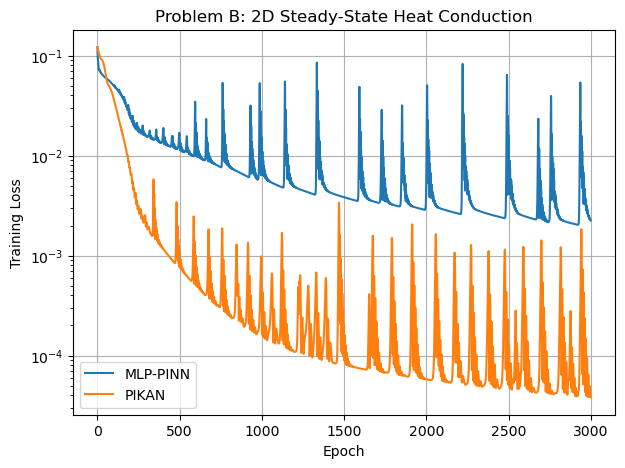

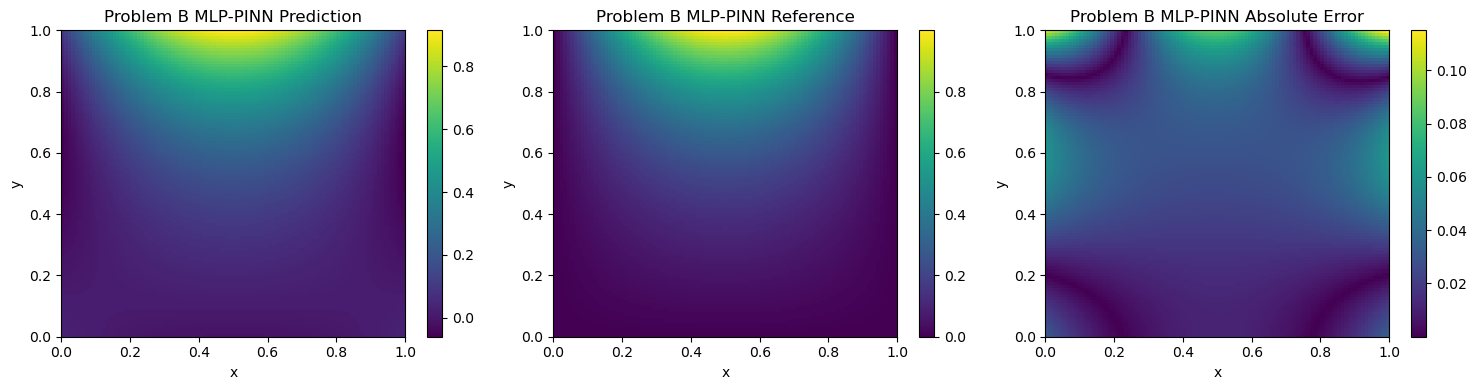

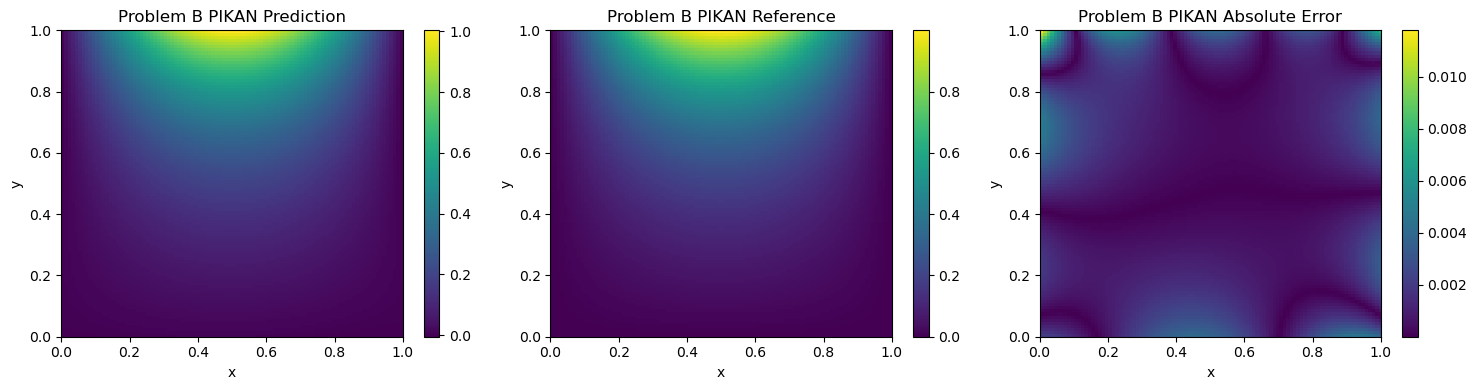

,Problem,Model,Params,Final Loss,Final PDE Loss,Final BC Loss,Relative L2 Error,Training Time,Epoch < 1e-4
0,B: 2D steady-state conduction,MLP-PINN,12737,0.002248,0.000378,0.001869,0.104098,51.355450,NaN
1,B: 2D steady-state conduction,PIKAN,12600,0.000038,0.000029,0.000010,0.005386,358.958079,1290.0


In [27]:
# =========================
# Cell 4: Run Problem B
# =========================

EPOCHS_2D = 3000
LR_2D = 1e-3

print("\n================ Problem B: 2D Steady-State Heat Conduction ================")

data_b = make_data_laplace_2d(
    n_f=2000,
    n_b=500,
    device=device,
    seed=2026
)

model_mlp_b = MLP_PINN(hidden_dim=64, depth=4)
model_kan_b = KAN_PINN(hidden_dim=20)

print("MLP params:", count_params(model_mlp_b))
print("KAN params:", count_params(model_kan_b))
print("Parameter ratio:", count_params(model_kan_b) / count_params(model_mlp_b))

print("\nTraining MLP-PINN on Problem B...")
hist_mlp_b, time_mlp_b = train_2d_problem(
    model_mlp_b,
    data_b,
    total_loss_laplace_2d,
    epochs=EPOCHS_2D,
    lr=LR_2D,
    device=device
)

print("\nTraining PIKAN on Problem B...")
hist_kan_b, time_kan_b = train_2d_problem(
    model_kan_b,
    data_b,
    total_loss_laplace_2d,
    epochs=EPOCHS_2D,
    lr=LR_2D,
    device=device
)

l2_mlp_b = relative_l2_grid_2d(
    model_mlp_b,
    true_solution_laplace_2d,
    device=device
)

l2_kan_b = relative_l2_grid_2d(
    model_kan_b,
    true_solution_laplace_2d,
    device=device
)

print("\nProblem B Results")
print("MLP Relative L2:", l2_mlp_b)
print("KAN Relative L2:", l2_kan_b)
print("MLP time:", time_mlp_b)
print("KAN time:", time_kan_b)

plt.figure(figsize=(7, 5))
plt.semilogy(hist_mlp_b["loss"], label="MLP-PINN")
plt.semilogy(hist_kan_b["loss"], label="PIKAN")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Problem B: 2D Steady-State Heat Conduction")
plt.legend()
plt.grid(True)
plt.show()

plot_2d_result(
    model_mlp_b,
    true_solution_laplace_2d,
    title="Problem B MLP-PINN",
    device=device
)

plot_2d_result(
    model_kan_b,
    true_solution_laplace_2d,
    title="Problem B PIKAN",
    device=device
)

summary_b = pd.DataFrame([
    {
        "Problem": "B: 2D steady-state conduction",
        "Model": "MLP-PINN",
        "Params": count_params(model_mlp_b),
        "Final Loss": hist_mlp_b["loss"][-1],
        "Final PDE Loss": hist_mlp_b["pde"][-1],
        "Final BC Loss": hist_mlp_b["bc"][-1],
        "Relative L2 Error": l2_mlp_b,
        "Training Time": time_mlp_b,
        "Epoch < 1e-4": first_epoch_below(hist_mlp_b)
    },
    {
        "Problem": "B: 2D steady-state conduction",
        "Model": "PIKAN",
        "Params": count_params(model_kan_b),
        "Final Loss": hist_kan_b["loss"][-1],
        "Final PDE Loss": hist_kan_b["pde"][-1],
        "Final BC Loss": hist_kan_b["bc"][-1],
        "Relative L2 Error": l2_kan_b,
        "Training Time": time_kan_b,
        "Epoch < 1e-4": first_epoch_below(hist_kan_b)
    }
])

summary_b

In [28]:
# =========================
# Cell 5: Problem C definitions
# 2D heat conduction with Gaussian heat source
# PDE: u_xx + u_yy + Q(x,y) = 0
# =========================

def true_solution_gaussian_2d(x, y, sigma=0.18, x0=0.5, y0=0.5):
    """
    Manufactured localized temperature field.
    It is close to zero on boundaries because of sin(pi x) sin(pi y).
    """
    r2 = (x - x0) ** 2 + (y - y0) ** 2
    g = torch.exp(-r2 / (2 * sigma ** 2))
    return torch.sin(torch.pi * x) * torch.sin(torch.pi * y) * g


def gaussian_source_Q(x, y, sigma=0.18, x0=0.5, y0=0.5):
    """
    Define Q from the manufactured exact solution.

    PDE:
        u_xx + u_yy + Q = 0

    Therefore:
        Q = -(u_xx + u_yy)
    """
    x = x.clone().detach().requires_grad_(True)
    y = y.clone().detach().requires_grad_(True)

    u = true_solution_gaussian_2d(
        x,
        y,
        sigma=sigma,
        x0=x0,
        y0=y0
    )

    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_y = torch.autograd.grad(
        u, y,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    u_yy = torch.autograd.grad(
        u_y, y,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0]

    Q = -(u_xx + u_yy)

    return Q.detach()


def make_data_gaussian_2d(n_f=2000, n_b=500, device="cpu", seed=2027):
    torch.manual_seed(seed)

    # Interior collocation points
    x_f = torch.rand(n_f, 1, device=device)
    y_f = torch.rand(n_f, 1, device=device)

    # Zero boundary points
    x_b, y_b, u_b = make_2d_boundary_data(
        n_b=n_b,
        device=device,
        boundary_type="gaussian"
    )

    return {
        "x_f": x_f,
        "y_f": y_f,
        "x_b": x_b,
        "y_b": y_b,
        "u_b": u_b
    }


def total_loss_gaussian_2d(model, data):
    """
    Loss = PDE residual loss + boundary loss.

    PDE residual:
        u_xx + u_yy + Q(x,y) = 0
    """
    lap = laplacian_2d(model, data["x_f"], data["y_f"])
    Q = gaussian_source_Q(data["x_f"], data["y_f"])

    residual = lap + Q
    loss_pde = torch.mean(residual ** 2)

    u_pred_b = model(data["x_b"], data["y_b"])
    loss_bc = torch.mean((u_pred_b - data["u_b"]) ** 2)

    loss = loss_pde + loss_bc

    logs = {
        "pde": loss_pde.item(),
        "bc": loss_bc.item()
    }

    return loss, logs


================ Problem C: 2D Gaussian Heat Source ================
MLP params: 12737
KAN params: 12600
Parameter ratio: 0.9892439349925414

Training MLP-PINN on Problem C...
Epoch 0, Loss=2.828053e+02, PDE=2.828037e+02, BC=1.589668e-03
Epoch 500, Loss=5.099634e-02, PDE=4.949635e-02, BC=1.499992e-03
Epoch 1000, Loss=6.555627e-03, PDE=6.231809e-03, BC=3.238179e-04
Epoch 1500, Loss=3.202241e-03, PDE=2.920068e-03, BC=2.821731e-04
Epoch 2000, Loss=1.720614e-01, PDE=1.717801e-01, BC=2.813423e-04
Epoch 2500, Loss=2.943519e-03, PDE=2.699449e-03, BC=2.440699e-04

Training PIKAN on Problem C...
Epoch 0, Loss=2.827810e+02, PDE=2.827810e+02, BC=6.221288e-06
Epoch 500, Loss=5.144259e-01, PDE=3.096461e-01, BC=2.047798e-01
Epoch 1000, Loss=6.577922e-02, PDE=6.477086e-02, BC=1.008359e-03
Epoch 1500, Loss=3.383944e-02, PDE=3.340447e-02, BC=4.349714e-04
Epoch 2000, Loss=2.546601e-02, PDE=2.519843e-02, BC=2.675763e-04
Epoch 2500, Loss=1.945092e-02, PDE=1.926559e-02, BC=1.853346e-04

Problem C Results


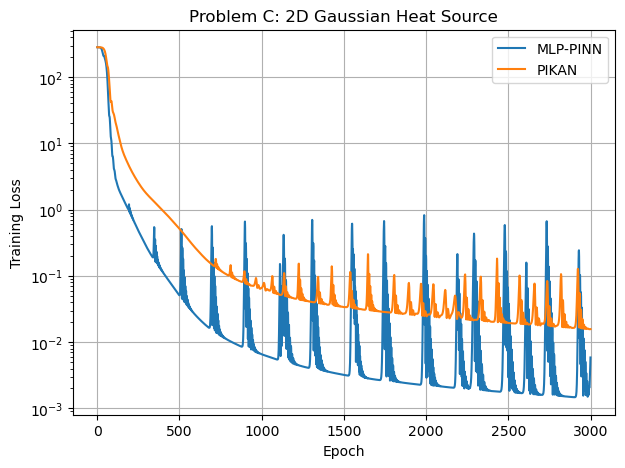

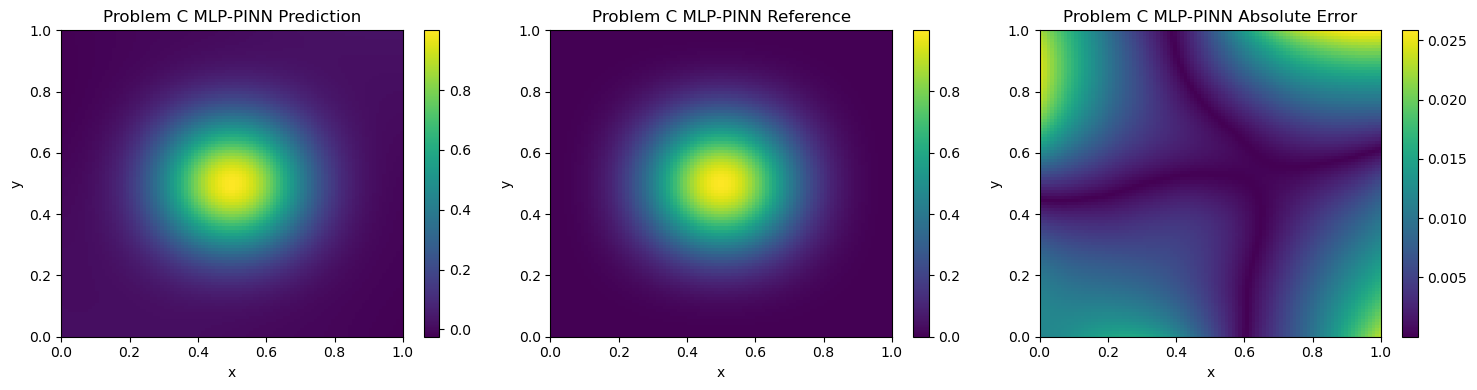

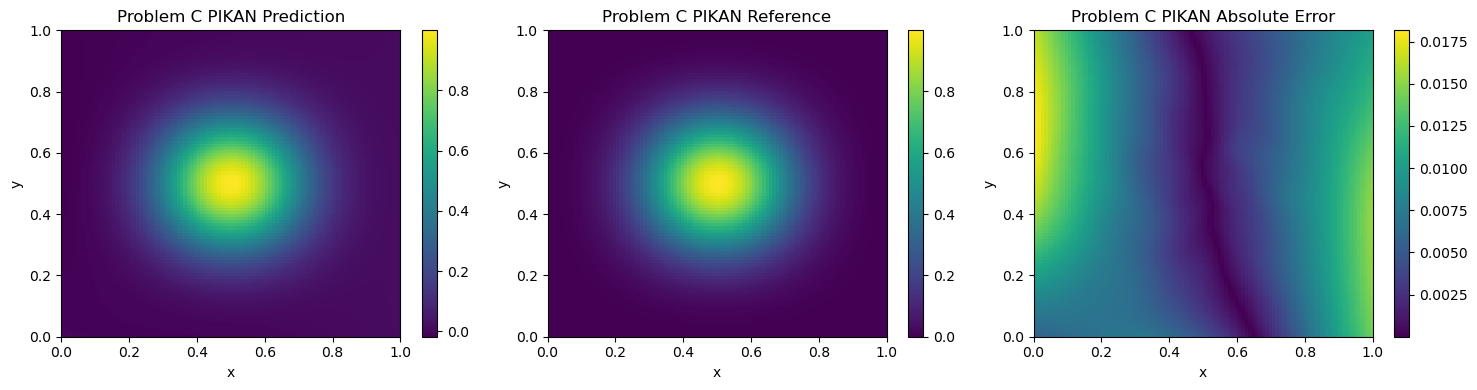

/tmp/ipykernel_427/1841920742.py:108: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary_bc = pd.concat([summary_b, summary_c], ignore_index=True)


,Problem,Model,Params,Final Loss,Final PDE Loss,Final BC Loss,Relative L2 Error,Training Time,Epoch < 1e-4
0,B: 2D steady-state conduction,MLP-PINN,12737,0.002248,0.000378,0.001869,0.104098,51.355450,NaN
1,B: 2D steady-state conduction,PIKAN,12600,0.000038,0.000029,0.000010,0.005386,358.958079,1290.0
2,C: 2D Gaussian heat source,MLP-PINN,12737,0.005869,0.005642,0.000227,0.032241,77.111747,NaN
3,C: 2D Gaussian heat source,PIKAN,12600,0.015722,0.015590,0.000132,0.030087,371.674396,NaN


In [29]:
# =========================
# Cell 6: Run Problem C and final summary
# =========================

print("\n================ Problem C: 2D Gaussian Heat Source ================")

data_c = make_data_gaussian_2d(
    n_f=2000,
    n_b=500,
    device=device,
    seed=2027
)

model_mlp_c = MLP_PINN(hidden_dim=64, depth=4)
model_kan_c = KAN_PINN(hidden_dim=20)

print("MLP params:", count_params(model_mlp_c))
print("KAN params:", count_params(model_kan_c))
print("Parameter ratio:", count_params(model_kan_c) / count_params(model_mlp_c))

print("\nTraining MLP-PINN on Problem C...")
hist_mlp_c, time_mlp_c = train_2d_problem(
    model_mlp_c,
    data_c,
    total_loss_gaussian_2d,
    epochs=EPOCHS_2D,
    lr=LR_2D,
    device=device
)

print("\nTraining PIKAN on Problem C...")
hist_kan_c, time_kan_c = train_2d_problem(
    model_kan_c,
    data_c,
    total_loss_gaussian_2d,
    epochs=EPOCHS_2D,
    lr=LR_2D,
    device=device
)

l2_mlp_c = relative_l2_grid_2d(
    model_mlp_c,
    true_solution_gaussian_2d,
    device=device
)

l2_kan_c = relative_l2_grid_2d(
    model_kan_c,
    true_solution_gaussian_2d,
    device=device
)

print("\nProblem C Results")
print("MLP Relative L2:", l2_mlp_c)
print("KAN Relative L2:", l2_kan_c)
print("MLP time:", time_mlp_c)
print("KAN time:", time_kan_c)

plt.figure(figsize=(7, 5))
plt.semilogy(hist_mlp_c["loss"], label="MLP-PINN")
plt.semilogy(hist_kan_c["loss"], label="PIKAN")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Problem C: 2D Gaussian Heat Source")
plt.legend()
plt.grid(True)
plt.show()

plot_2d_result(
    model_mlp_c,
    true_solution_gaussian_2d,
    title="Problem C MLP-PINN",
    device=device
)

plot_2d_result(
    model_kan_c,
    true_solution_gaussian_2d,
    title="Problem C PIKAN",
    device=device
)

summary_c = pd.DataFrame([
    {
        "Problem": "C: 2D Gaussian heat source",
        "Model": "MLP-PINN",
        "Params": count_params(model_mlp_c),
        "Final Loss": hist_mlp_c["loss"][-1],
        "Final PDE Loss": hist_mlp_c["pde"][-1],
        "Final BC Loss": hist_mlp_c["bc"][-1],
        "Relative L2 Error": l2_mlp_c,
        "Training Time": time_mlp_c,
        "Epoch < 1e-4": first_epoch_below(hist_mlp_c)
    },
    {
        "Problem": "C: 2D Gaussian heat source",
        "Model": "PIKAN",
        "Params": count_params(model_kan_c),
        "Final Loss": hist_kan_c["loss"][-1],
        "Final PDE Loss": hist_kan_c["pde"][-1],
        "Final BC Loss": hist_kan_c["bc"][-1],
        "Relative L2 Error": l2_kan_c,
        "Training Time": time_kan_c,
        "Epoch < 1e-4": first_epoch_below(hist_kan_c)
    }
])

summary_bc = pd.concat([summary_b, summary_c], ignore_index=True)
summary_bc

## Report Template

Use the following text in the final report.

### Method

We first implemented an MLP-PINN baseline for the 1D heat equation. The neural network takes \((x,t)\) as input and predicts \(u(x,t)\). The loss consists of the PDE residual loss, boundary condition loss, and initial condition loss.

Then we implemented PIKAN by replacing only the MLP backbone with a KAN backbone. All other components were kept unchanged, including the heat equation, sampled training points, PDE residual loss, boundary loss, initial loss, optimizer, learning rate, and number of training epochs.

For a fair comparison, the trainable parameter count of the KAN model was matched to the MLP baseline as closely as possible by tuning the KAN hidden dimension. The models were compared using training loss curves, relative L2 error against the analytical solution, convergence speed, and sensitivity to learning rate and network depth.

### Evaluation Metrics

We report:
1. Relative L2 error against the analytical solution.
2. Final training loss.
3. PDE, boundary, and initial loss components.
4. Number of epochs needed to reach a target loss.
5. Trainable parameter count.
6. Sensitivity to learning rate and network depth.

### Expected Discussion

If PIKAN achieves lower loss or lower relative L2 error under a similar parameter count, it suggests that the KAN backbone provides better parameter efficiency for this PDE problem. If MLP-PINN performs better, the result is still reasonable because MLP-PINN is more stable and mature for PINN training, while KAN can be more sensitive to optimization and hyperparameter choices.